In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.metrics import r2_score, cohen_kappa_score

In [38]:
filename = r'..\data\results\game_dataset.csv'
df = pd.read_csv(filename)
df.rename(columns={'mode': 'condition'}, inplace=True)
df = df.loc[~df.subject.isin(['04AB', '24EK'])]

In [39]:
df_band = df.loc[df.event.isin([f'blast_step_{i}' for i in range(1, 9)] + ['overkill_step'])]
df_new = []
for subject in df.subject.unique():
    for cond in ['im', 'qm']:
        for n_game in df_band.loc[(df_band.subject == subject) & (df_band.condition == cond)]['n_game'].unique():
            for n_star in df_band.loc[(df_band.subject == subject) & (df_band.condition == cond) & (df_band.n_game == n_game)]['n_star'].unique():
                df_star_all = df_band.loc[(df_band.subject == subject) & (df_band.condition == cond) & (df_band.n_game == n_game) & (df_band.n_star == n_star)].copy()
                for filename in df_star_all.filename.unique():
                    df_star = df_star_all.loc[df_star_all.filename == filename]
                    n_overkill = 0
                    n_band = 0
                    for event in df_star.event.values:
                        ev = df_star.loc[df_star.event == event]
                        if event == 'overkill_step':
                            n_overkill += 1
                            event_name = f'outer_band_{n_overkill}'
                            decision = 0 if ev['decision'].values[0] == 'no_overkill' else 1
                        else:
                            n_band += 1
                            event_name = f'inner_band_{n_band}'
                            decision = 1 if ev['decision'].values[0] == 'success' else 0
                        new_event = {}
                        new_event['event_name'] = event_name
                        new_event['decision'] = decision
                        for name in ['subject', 'condition', 'res_timestamp', 'n_star', 'n_game', 'filename']:
                            new_event[name] = ev[name].values[0]
                        df_new.append(new_event)
                    if n_overkill < 4:
                        while n_overkill < 4:
                            n_overkill += 1
                            new_event = {}
                            new_event['event_name'] = f'outer_band_{n_overkill}'
                            new_event['decision'] = 0
                            for name in ['subject', 'condition', 'res_timestamp', 'n_star', 'n_game', 'filename']:
                                new_event[name] = ev[name].values[0]
                            df_new.append(new_event)  

In [40]:
df_band = pd.DataFrame(df_new)

In [41]:
df_band.head(5)

,event_name,decision,subject,condition,res_timestamp,n_star,n_game,filename
0,inner_band_1,0,01TG,im,418390807,9,1,im_log_game_1
1,inner_band_2,1,01TG,im,418391824,9,1,im_log_game_1
2,inner_band_3,1,01TG,im,418392862,9,1,im_log_game_1
3,inner_band_4,1,01TG,im,418393796,9,1,im_log_game_1
4,inner_band_5,1,01TG,im,418394825,9,1,im_log_game_1


In [42]:
# без первого и 2-х последних поясов
df_central = df_band.copy()

TP = [f'inner_band_{i}' for i in range(2, 7)]
TN = [f'outer_band_{i}' for i in range(1, 5)]
df_central = df_central.loc[(df_central.event_name.isin(TP + TN))]

df_central['label'] = 1
df_central.loc[df_central.event_name.isin(TN), 'label'] = 0 

df_r2 = []
for subject in df_central.subject.unique():
    for cond in ['im', 'qm']:
        for n_game in df_central.loc[(df_central.subject == subject) & (df_central.condition == cond)]['n_game'].unique():
            df_curr = df_central.loc[(df_central.subject == subject) & (df_central.condition == cond) & (df_central.n_game == n_game)]
            TPR = df_curr.loc[(df_curr.label == 1) & (df_curr.decision == 1)].shape[0] / df_curr.loc[df_curr.label == 1].shape[0]
            TNR = df_curr.loc[(df_curr.label == 0) & (df_curr.decision == 0)].shape[0] / df_curr.loc[df_curr.label == 0].shape[0]
            df_r2.append({
                'subject': subject, 
                'condition': cond, 
                'n_game': n_game, 
                'r2': r2_score(df_curr.label.values, df_curr.decision.values),
                'kappa': cohen_kappa_score(df_curr.label.values, df_curr.decision.values),
                'TPR': round(TPR * 100, 2),
                'TNR': round(TNR * 100, 2)
            })
df_r2 = pd.DataFrame(df_r2)

<Axes: xlabel='n_game', ylabel='TPR'>

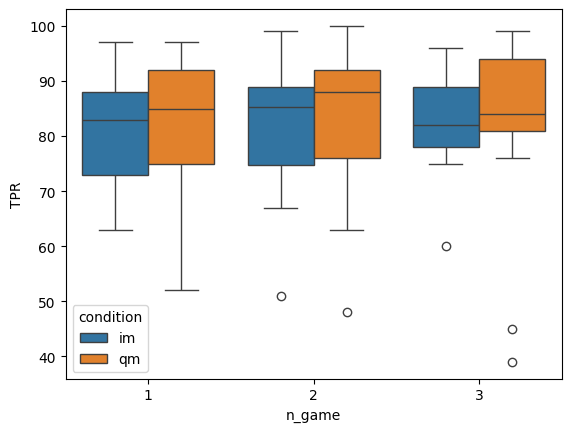

In [43]:
sns.boxplot(df_r2, x='n_game', y='TPR', hue='condition')

<Axes: xlabel='n_game', ylabel='TNR'>

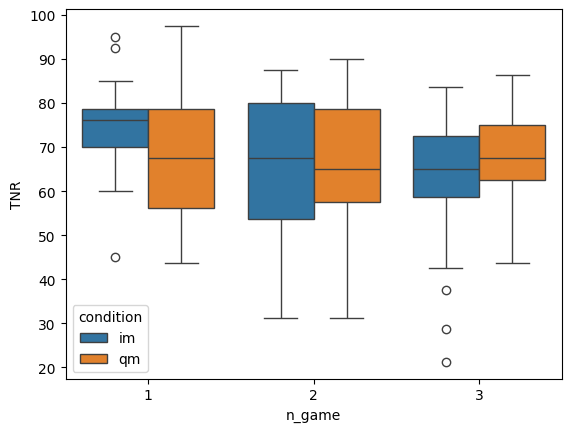

In [44]:
sns.boxplot(df_r2, x='n_game', y='TNR', hue='condition')

<Axes: xlabel='n_game', ylabel='kappa'>

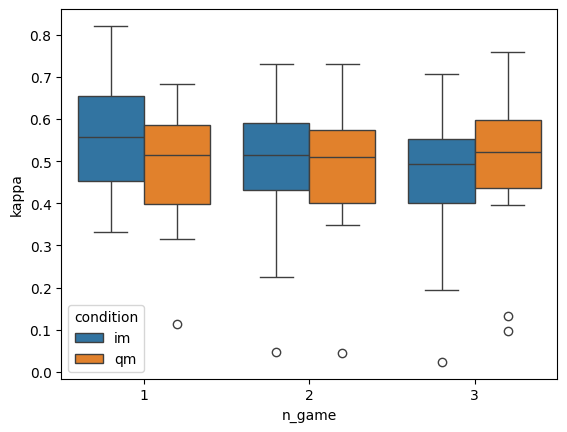

In [45]:
sns.boxplot(df_r2, x='n_game', y='kappa', hue='condition')

In [69]:
# без первого и 2-х последних поясов
df_central = df_band.copy()

df_central['label'] = 1
df_central.loc[df_central.event_name.isin(TN), 'label'] = 0 

df_game = []
for subject in df_central.subject.unique():
    for cond in ['im', 'qm']:
        for n_game in df_central.loc[(df_central.subject == subject) & (df_central.condition == cond)]['n_game'].unique():
            df_curr = df_central.loc[(df_central.subject == subject) & (df_central.condition == cond) & (df_central.n_game == n_game)]
            n_success = 0
            TNRs = []
            for star in df_curr.n_star.unique():
                df_star = df_curr.loc[df_curr.n_star == star]
                correct = df_star.loc[((df_star.label == 1) & (df_star.decision == 1)) | ((df_star.label == 0) & (df_star.decision == 0))].shape[0]
                p_correct = round(correct / df_star.shape[0] * 100, 2)
                success = 1 if p_correct > 50 else 0
                n_success += success
                TNRs.append(df_star.loc[(df_star.label == 0) & (df_star.decision == 0)].shape[0] / df_star.loc[(df_star.label == 0)].shape[0])
            df_game.append({
                'subject': subject, 
                'condition': cond, 
                'n_game': n_game, 
                'p_correct': round(n_success / df_curr.n_star.unique().shape[0] * 100, 2),
                'TNR': np.mean(TNRs)
            })
df_game = pd.DataFrame(df_game)

<Axes: xlabel='n_game', ylabel='TNR'>

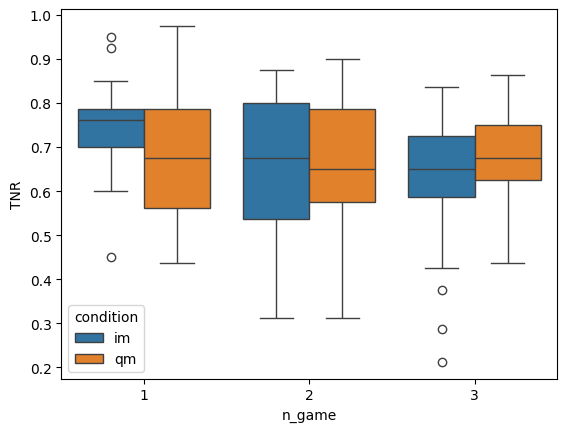

In [70]:
sns.boxplot(df_game, x='n_game', y='TNR', hue='condition')

<Axes: xlabel='n_game', ylabel='p_correct'>

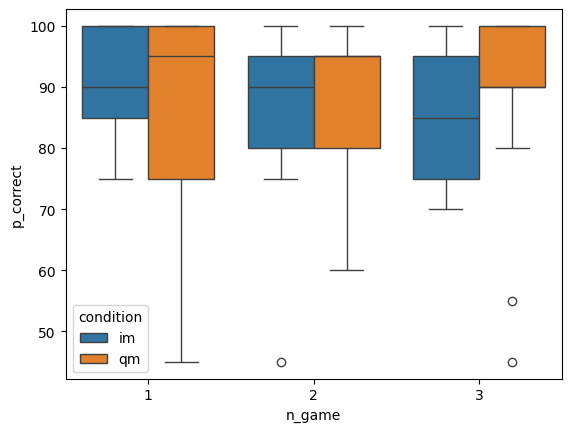

In [47]:
sns.boxplot(df_game, x='n_game', y='p_correct', hue='condition')

<Axes: xlabel='subject', ylabel='p_correct'>

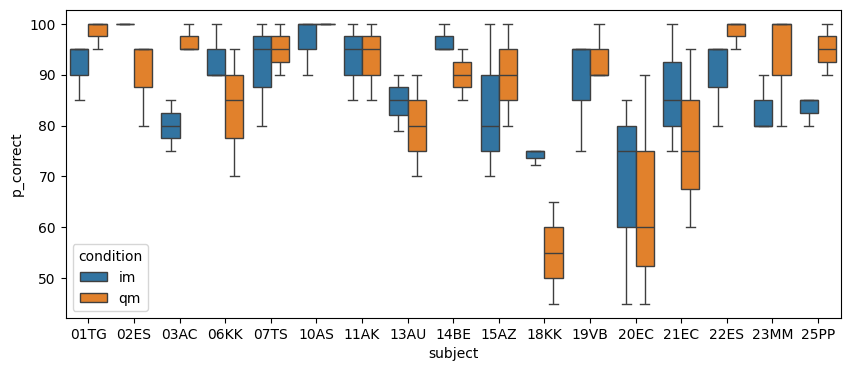

In [48]:
plt.figure(figsize=(10, 4))
sns.boxplot(df_game, x='subject', y='p_correct', hue='condition')

In [66]:
df_hh = []
for subject in df.subject.unique():
    for cond in ['im', 'qm']:
        for n_game in df.loc[(df.subject == subject) & (df.condition == cond)]['n_game'].unique():
            df_curr = df.loc[(df.subject == subject) & (df.condition == cond) & (df.n_game == n_game)]
            n_star = sum(df_curr.n_star.unique() != -1)
            n = 0
            for star in df_curr.n_star.unique():
                df_star = df_curr.loc[df_curr.n_star == star]
                if df_star.loc[df_star.event == 'start_holiday_home'].shape[0] == 0:
                    n += 1
            if n_star != 20:
                print(n_star)
            n_hh = df_curr.loc[df_curr.event == 'start_holiday_home'].shape[0]
            df_hh.append({
                'subject': subject, 
                'condition': cond, 
                'n_game': n_game, 
                'p_hh': round(n/n_star * 100, 2)
            })
df_hh = pd.DataFrame(df_hh)

10
10
10
10
19
10
10
10


<Axes: xlabel='subject', ylabel='p_hh'>

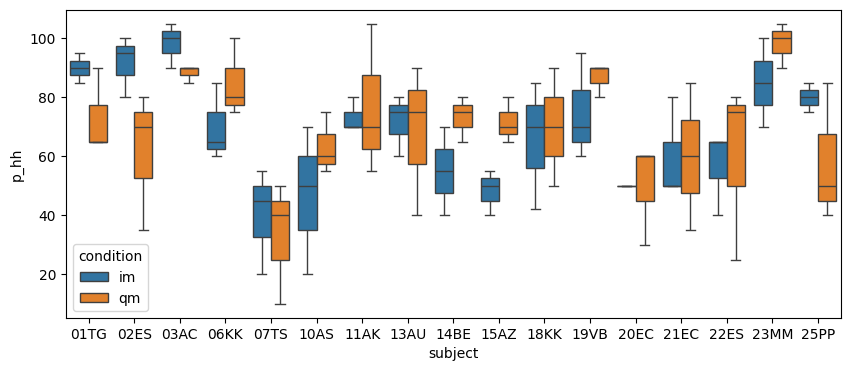

In [67]:
plt.figure(figsize=(10, 4))
sns.boxplot(df_hh, x='subject', y='p_hh', hue='condition')

<Axes: xlabel='n_game', ylabel='p_hh'>

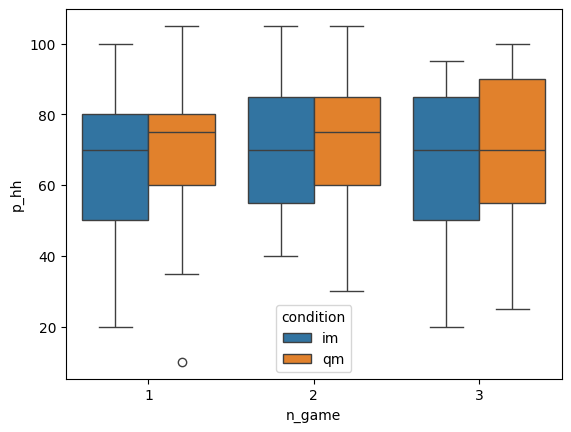

In [68]:
sns.boxplot(df_hh, x='n_game', y='p_hh', hue='condition')